In [ ]:
# !rm -rf /content/drive

In [ ]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


# 2단계: 라이브러리와 경로 설정

In [ ]:
import torch

print("CUDA 사용 가능:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU 이름:", torch.cuda.get_device_name(0))

CUDA 사용 가능: True
GPU 이름: Tesla T4


In [ ]:
import os
import gc
import json
import random
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import IterableDataset, DataLoader

from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    cohen_kappa_score,
    classification_report,
    confusion_matrix,
)

print("PyTorch 버전:", torch.__version__)
print("CUDA 사용 가능:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("현재 GPU가 활성화되지 않았습니다.")
    print("Colab 메뉴에서 런타임 → 런타임 유형 변경 → T4 GPU를 선택하세요.")

PyTorch 버전: 2.11.0+cu128
CUDA 사용 가능: True
GPU: Tesla T4


In [ ]:
# ============================================================
# Google Drive 경로
# ============================================================

PROJECT_PATH = Path("/content/drive/MyDrive/SleepEDF")

PROCESSED_PATH = PROJECT_PATH / "processed"
METADATA_PATH = PROJECT_PATH / "metadata"

OUTPUT_PATH = PROJECT_PATH / "outputs"
MODEL_PATH = PROJECT_PATH / "models"
SPLIT_PATH = PROJECT_PATH / "splits"

OUTPUT_PATH.mkdir(parents=True, exist_ok=True)
MODEL_PATH.mkdir(parents=True, exist_ok=True)
SPLIT_PATH.mkdir(parents=True, exist_ok=True)

print("프로젝트 경로:", PROJECT_PATH)
print("NPZ 경로:", PROCESSED_PATH)
print("메타데이터 경로:", METADATA_PATH)

프로젝트 경로: /content/drive/MyDrive/SleepEDF
NPZ 경로: /content/drive/MyDrive/SleepEDF/processed
메타데이터 경로: /content/drive/MyDrive/SleepEDF/metadata


# 3단계: 파일 존재 여부 확인

In [ ]:
summary_path = METADATA_PATH / "dataset_summary.csv"

if not PROJECT_PATH.exists():
    raise FileNotFoundError(
        f"프로젝트 폴더가 없습니다: {PROJECT_PATH}"
    )

if not PROCESSED_PATH.exists():
    raise FileNotFoundError(
        f"processed 폴더가 없습니다: {PROCESSED_PATH}"
    )

if not summary_path.exists():
    raise FileNotFoundError(
        f"dataset_summary.csv가 없습니다: {summary_path}"
    )

npz_files = sorted(PROCESSED_PATH.glob("*.npz"))

print("NPZ 파일 수:", len(npz_files))
print("요약 파일:", summary_path)

if len(npz_files) != 153:
    print(
        f"주의: 예상 NPZ 수는 153개지만 현재 {len(npz_files)}개입니다."
    )

print("\n처음 5개 파일")

for file_path in npz_files[:5]:
    print(file_path.name)

NPZ 파일 수: 153
요약 파일: /content/drive/MyDrive/SleepEDF/metadata/dataset_summary.csv

처음 5개 파일
SC4001E0.npz
SC4002E0.npz
SC4011E0.npz
SC4012E0.npz
SC4021E0.npz


# 4단계: NPZ 파일 하나 검증

In [ ]:
sample_file = npz_files[0]

with np.load(sample_file, allow_pickle=False) as data:
    print("파일:", sample_file.name)
    print("저장 항목:", data.files)
    print("X shape:", data["X"].shape)
    print("y shape:", data["y"].shape)
    print("record_id:", data["record_id"].item())
    print("subject_id:", data["subject_id"].item())
    print("채널:", data["channel_name"].item())
    print("샘플링 주파수:", data["sfreq"].item())
    print(
        "라벨 분포:",
        np.unique(data["y"], return_counts=True),
    )
    # 이런 형태 나와야함
# X shape: (기록별 Epoch 수, 1, 3000)
# y shape: (기록별 Epoch 수,)

파일: SC4001E0.npz
저장 항목: ['X', 'y', 'epoch_onset_sec', 'record_id', 'subject_id', 'pair_key', 'hypnogram_id', 'psg_file_name', 'hyp_file_name', 'channel_name', 'original_sfreq', 'sfreq', 'epoch_duration_sec', 'low_cut_hz', 'high_cut_hz', 'label_ids', 'label_names', 'wake_margin_minutes', 'events_before_trim', 'events_after_trim', 'epoch_zscore', 'processing_config_json', 'created_at']
X shape: (841, 1, 3000)
y shape: (841,)
record_id: SC4001E0
subject_id: SC400
채널: EEG Fpz-Cz
샘플링 주파수: 100.0
라벨 분포: (array([0, 1, 2, 3, 4]), array([188,  58, 250, 220, 125]))


# 5단계: 메타데이터 불러오기

In [ ]:
summary_df = pd.read_csv(summary_path)

print("메타데이터 shape:", summary_df.shape)
print("컬럼:")
print(summary_df.columns.tolist())

display(summary_df.head())
required_columns = {
    "record_id",
    "subject_id",
    "epoch_count",
    "count_W",
    "count_N1",
    "count_N2",
    "count_N3",
    "count_REM",
}

missing_columns = required_columns - set(summary_df.columns)

if missing_columns:
    raise ValueError(
        f"dataset_summary.csv에 필수 컬럼이 없습니다: "
        f"{sorted(missing_columns)}"
    )

print("기록 수:", len(summary_df))
print("피험자 수:", summary_df["subject_id"].nunique())
print("전체 Epoch 수:", summary_df["epoch_count"].sum())

메타데이터 shape: (153, 32)
컬럼:
['status', 'pair_key', 'record_id', 'subject_id', 'hypnogram_id', 'psg_file', 'hyp_file', 'output_file', 'epoch_count', 'channel_count', 'samples_per_epoch', 'original_sfreq', 'final_sfreq', 'duration_hours', 'processing_seconds', 'file_size_mb', 'count_W', 'ratio_W', 'count_N1', 'ratio_N1', 'count_N2', 'ratio_N2', 'count_N3', 'ratio_N3', 'count_REM', 'ratio_REM', 'original_duration_hours', 'events_before_trim', 'events_after_trim', 'events_removed', 'annotation_count', 'annotation_types']


,status,pair_key,record_id,subject_id,hypnogram_id,psg_file,hyp_file,output_file,epoch_count,channel_count,...,count_N3,ratio_N3,count_REM,ratio_REM,original_duration_hours,events_before_trim,events_after_trim,events_removed,annotation_count,annotation_types
0,skipped_existing,SC4001,SC4001E0,SC400,SC4001EC,SC4001E0-PSG.edf,SC4001EC-Hypnogram.edf,SC4001E0.npz,841,1,...,220,0.261593,125,0.148633,NaN,NaN,NaN,NaN,NaN,NaN
1,skipped_existing,SC4002,SC4002E0,SC400,SC4002EC,SC4002E0-PSG.edf,SC4002EC-Hypnogram.edf,SC4002E0.npz,1127,1,...,297,0.263531,215,0.190772,NaN,NaN,NaN,NaN,NaN,NaN
2,skipped_existing,SC4011,SC4011E0,SC401,SC4011EH,SC4011E0-PSG.edf,SC4011EH-Hypnogram.edf,SC4011E0.npz,1103,1,...,105,0.095195,170,0.154125,NaN,NaN,NaN,NaN,NaN,NaN
3,skipped_existing,SC4012,SC4012E0,SC401,SC4012EC,SC4012E0-PSG.edf,SC4012EC-Hypnogram.edf,SC4012E0.npz,1186,1,...,96,0.080944,176,0.148398,NaN,NaN,NaN,NaN,NaN,NaN
4,skipped_existing,SC4021,SC4021E0,SC402,SC4021EH,SC4021E0-PSG.edf,SC4021EH-Hypnogram.edf,SC4021E0.npz,1025,1,...,95,0.092683,163,0.159024,NaN,NaN,NaN,NaN,NaN,NaN


기록 수: 153
피험자 수: 78
전체 Epoch 수: 195479


# 6단계: 실제 NPZ 존재 여부 검사

In [ ]:
summary_df["npz_path"] = summary_df["record_id"].apply(
    lambda record_id: str(
        PROCESSED_PATH / f"{record_id}.npz"
    )
)

summary_df["npz_exists"] = summary_df["npz_path"].apply(
    lambda path: Path(path).exists()
)

missing_npz_df = summary_df[
    ~summary_df["npz_exists"]
].copy()

print("NPZ가 존재하는 기록:", summary_df["npz_exists"].sum())
print("NPZ가 없는 기록:", len(missing_npz_df))

if len(missing_npz_df) > 0:
    display(
        missing_npz_df[
            ["record_id", "subject_id", "npz_path"]
        ]
    )

    raise FileNotFoundError(
        "일부 메타데이터에 대응하는 NPZ 파일이 없습니다."
    )

NPZ가 존재하는 기록: 153
NPZ가 없는 기록: 0


# 7단계: 피험자 단위 Train/Validation/Test 분할

In [ ]:
# Train      70%
# Validation 15%
# Test       15%

RANDOM_SEED = 42

# 전체 중 15%를 Test로 분리
test_splitter = GroupShuffleSplit(
    n_splits=1,
    test_size=0.15,
    random_state=RANDOM_SEED,
)

train_valid_idx, test_idx = next(
    test_splitter.split(
        summary_df,
        groups=summary_df["subject_id"],
    )
)

train_valid_df = summary_df.iloc[
    train_valid_idx
].copy()

test_df = summary_df.iloc[
    test_idx
].copy()

# Train+Validation 중 약 17.647%를 Validation으로 사용
# 전체 기준으로 약 15%가 됨
validation_ratio_within_train_valid = 0.15 / 0.85

validation_splitter = GroupShuffleSplit(
    n_splits=1,
    test_size=validation_ratio_within_train_valid,
    random_state=RANDOM_SEED,
)

train_idx, validation_idx = next(
    validation_splitter.split(
        train_valid_df,
        groups=train_valid_df["subject_id"],
    )
)

train_df = train_valid_df.iloc[
    train_idx
].copy()

validation_df = train_valid_df.iloc[
    validation_idx
].copy()

train_df = train_df.sort_values(
    ["subject_id", "record_id"]
).reset_index(drop=True)

validation_df = validation_df.sort_values(
    ["subject_id", "record_id"]
).reset_index(drop=True)

test_df = test_df.sort_values(
    ["subject_id", "record_id"]
).reset_index(drop=True)

# 8단계: 데이터 누수 검증

In [ ]:
train_subjects = set(train_df["subject_id"])
validation_subjects = set(validation_df["subject_id"])
test_subjects = set(test_df["subject_id"])

train_validation_overlap = (
    train_subjects & validation_subjects
)

train_test_overlap = (
    train_subjects & test_subjects
)

validation_test_overlap = (
    validation_subjects & test_subjects
)

print(
    "Train-Validation 피험자 중복:",
    len(train_validation_overlap),
)

print(
    "Train-Test 피험자 중복:",
    len(train_test_overlap),
)

print(
    "Validation-Test 피험자 중복:",
    len(validation_test_overlap),
)

assert len(train_validation_overlap) == 0
assert len(train_test_overlap) == 0
assert len(validation_test_overlap) == 0

print("\n피험자 단위 분할 검증 성공")

Train-Validation 피험자 중복: 0
Train-Test 피험자 중복: 0
Validation-Test 피험자 중복: 0

피험자 단위 분할 검증 성공


# 9단계: 분할 결과 확인

In [ ]:
def print_split_summary(
    name: str,
    split_df: pd.DataFrame,
) -> None:
    epoch_count = int(
        split_df["epoch_count"].sum()
    )

    print("=" * 70)
    print(name)
    print("-" * 70)
    print("기록 수:", len(split_df))
    print("피험자 수:", split_df["subject_id"].nunique())
    print("Epoch 수:", f"{epoch_count:,}")
    print(
        "전체 대비 Epoch 비율:",
        f"{epoch_count / summary_df['epoch_count'].sum() * 100:.2f}%",
    )


print_split_summary("TRAIN", train_df)
print_split_summary("VALIDATION", validation_df)
print_split_summary("TEST", test_df)

TRAIN
----------------------------------------------------------------------
기록 수: 106
피험자 수: 54
Epoch 수: 133,570
전체 대비 Epoch 비율: 68.33%
VALIDATION
----------------------------------------------------------------------
기록 수: 23
피험자 수: 12
Epoch 수: 31,252
전체 대비 Epoch 비율: 15.99%
TEST
----------------------------------------------------------------------
기록 수: 24
피험자 수: 12
Epoch 수: 30,657
전체 대비 Epoch 비율: 15.68%


# 10단계: 클래스 분포 확인

In [ ]:
CLASS_NAMES = ["W", "N1", "N2", "N3", "REM"]

COUNT_COLUMNS = [
    "count_W",
    "count_N1",
    "count_N2",
    "count_N3",
    "count_REM",
]


def get_split_class_distribution(
    split_df: pd.DataFrame,
) -> pd.DataFrame:
    counts = (
        split_df[COUNT_COLUMNS]
        .sum()
        .to_numpy(dtype=np.int64)
    )

    total = counts.sum()

    ratios = counts / total

    return pd.DataFrame(
        {
            "label": np.arange(5),
            "stage": CLASS_NAMES,
            "count": counts,
            "ratio": ratios,
            "ratio_percent": ratios * 100,
        }
    )


train_distribution = get_split_class_distribution(train_df)
validation_distribution = get_split_class_distribution(validation_df)
test_distribution = get_split_class_distribution(test_df)

print("Train 클래스 분포")
display(train_distribution)

print("Validation 클래스 분포")
display(validation_distribution)

print("Test 클래스 분포")
display(test_distribution)

Train 클래스 분포


,label,stage,count,ratio,ratio_percent
0,0,W,44253,0.331309,33.130943
1,1,N1,15438,0.115580,11.557985
2,2,N2,46882,0.350992,35.099199
3,3,N3,9387,0.070278,7.027776
4,4,REM,17610,0.131841,13.184098


Validation 클래스 분포


,label,stage,count,ratio,ratio_percent
0,0,W,11930,0.381736,38.173557
1,1,N1,2561,0.081947,8.194676
2,2,N2,10650,0.340778,34.077819
3,3,N3,2086,0.066748,6.674773
4,4,REM,4025,0.128792,12.879176


Test 클래스 분포


,label,stage,count,ratio,ratio_percent
0,0,W,9768,0.318622,31.862217
1,1,N1,3523,0.114917,11.491666
2,2,N2,11600,0.378380,37.838014
3,3,N3,1566,0.051081,5.108132
4,4,REM,4200,0.137000,13.699971


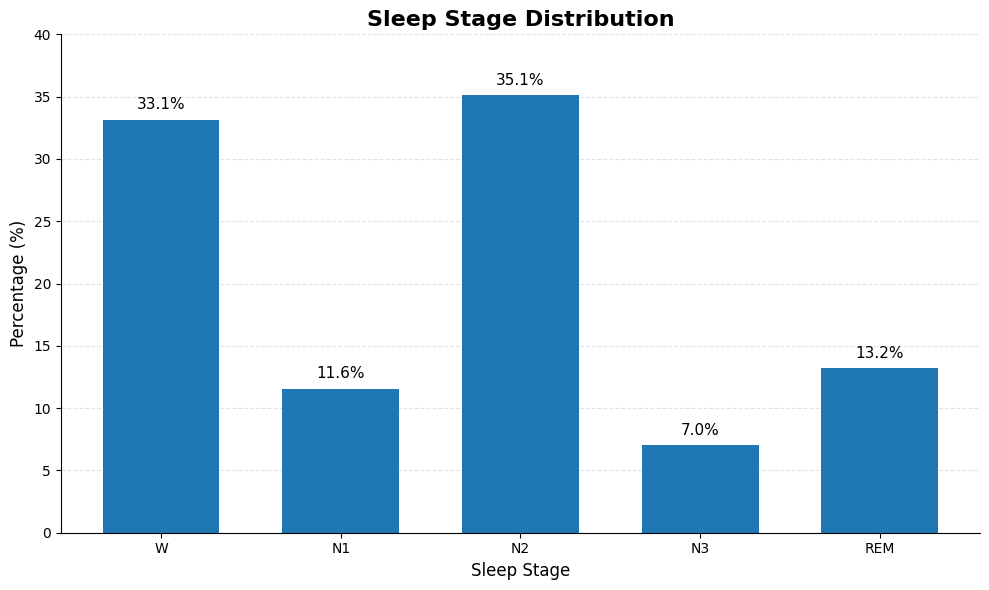

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# 데이터
stage_df = pd.DataFrame({
    "stage": ["W", "N1", "N2", "N3", "REM"],
    "ratio_percent": [33.130943, 11.557985, 35.099199, 7.027776, 13.184098]
})

# 그래프 생성
fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.bar(
    stage_df["stage"],
    stage_df["ratio_percent"],
    width=0.65
)

# 막대 위에 비율 표시
for bar, percent in zip(bars, stage_df["ratio_percent"]):
    ax.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.6,
        f"{percent:.1f}%",
        ha="center",
        va="bottom",
        fontsize=11
    )

ax.set_title("Sleep Stage Distribution", fontsize=16, fontweight="bold")
ax.set_xlabel("Sleep Stage", fontsize=12)
ax.set_ylabel("Percentage (%)", fontsize=12)

ax.set_ylim(0, 40)
ax.grid(axis="y", linestyle="--", alpha=0.35)
ax.set_axisbelow(True)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

# 11단계: 분할 결과 CSV 저장

In [ ]:
split_columns = [
    "record_id",
    "subject_id",
    "npz_path",
    "epoch_count",
    "count_W",
    "count_N1",
    "count_N2",
    "count_N3",
    "count_REM",
]

train_df[split_columns].to_csv(
    SPLIT_PATH / "train_records.csv",
    index=False,
    encoding="utf-8-sig",
)

validation_df[split_columns].to_csv(
    SPLIT_PATH / "validation_records.csv",
    index=False,
    encoding="utf-8-sig",
)

test_df[split_columns].to_csv(
    SPLIT_PATH / "test_records.csv",
    index=False,
    encoding="utf-8-sig",
)

print("분할 결과 저장 완료:", SPLIT_PATH)

분할 결과 저장 완료: /content/drive/MyDrive/SleepEDF/splits


# 12단계: 재실행 시 저장된 분할 불러오기

In [ ]:
train_df = pd.read_csv(
    SPLIT_PATH / "train_records.csv"
)

validation_df = pd.read_csv(
    SPLIT_PATH / "validation_records.csv"
)

test_df = pd.read_csv(
    SPLIT_PATH / "test_records.csv"
)

print("Train 기록:", len(train_df))
print("Validation 기록:", len(validation_df))
print("Test 기록:", len(test_df))

Train 기록: 106
Validation 기록: 23
Test 기록: 24


# 13단계: 클래스 가중치 계산

In [ ]:
train_class_counts = (
    train_df[COUNT_COLUMNS]
    .sum()
    .to_numpy(dtype=np.float64)
)

total_train_samples = train_class_counts.sum()
number_of_classes = len(train_class_counts)

class_weights = (
    total_train_samples
    / (
        number_of_classes
        * train_class_counts
    )
)

class_weights_tensor = torch.tensor(
    class_weights,
    dtype=torch.float32,
)

class_weight_df = pd.DataFrame(
    {
        "label": np.arange(5),
        "stage": CLASS_NAMES,
        "count": train_class_counts.astype(int),
        "weight": class_weights,
    }
)

display(class_weight_df)

,label,stage,count,weight
0,0,W,44253,0.603665
1,1,N1,15438,1.730405
2,2,N2,46882,0.569814
3,3,N3,9387,2.845851
4,4,REM,17610,1.516979


# 14단계: 재현성 설정

In [ ]:
def set_seed(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)

    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


set_seed(RANDOM_SEED)

print("랜덤 시드 설정 완료:", RANDOM_SEED)

랜덤 시드 설정 완료: 42


# 15단계: 메모리 효율적인 Sleep-EDF Dataset 작성

In [ ]:
# 전체 데이터는 압축 해제하면 2GB보다 훨씬 커질 수 있으므로 한 번에 전부 RAM에 올리지 않습니다.
# 아래 Dataset은 기록별 .npz 파일을 하나씩 읽고, 각 기록 내부 Epoch 순서를 섞어서 전달합니다.

class SleepEDFIterableDataset(IterableDataset):
    """
    기록별 NPZ 파일을 하나씩 읽는 메모리 효율적인 Dataset.

    Train에서는:
    - 기록 순서를 무작위로 변경
    - 기록 내부 Epoch 순서를 무작위로 변경

    Validation/Test에서는:
    - 고정된 순서로 읽음
    """

    def __init__(
        self,
        records_df: pd.DataFrame,
        shuffle: bool = False,
        seed: int = 42,
    ) -> None:
        super().__init__()

        self.records = records_df[
            ["record_id", "subject_id", "npz_path"]
        ].to_dict("records")

        self.shuffle = shuffle
        self.seed = seed
        self.epoch = 0

    def set_epoch(self, epoch: int) -> None:
        self.epoch = epoch

    def __iter__(self):
        random_generator = np.random.default_rng(
            self.seed + self.epoch
        )

        record_indices = np.arange(
            len(self.records)
        )

        if self.shuffle:
            random_generator.shuffle(
                record_indices
            )

        for record_index in record_indices:
            record = self.records[
                int(record_index)
            ]

            npz_path = Path(
                record["npz_path"]
            )

            if not npz_path.exists():
                raise FileNotFoundError(
                    f"NPZ 파일이 없습니다: {npz_path}"
                )

            with np.load(
                npz_path,
                allow_pickle=False,
            ) as data:
                X = data["X"].astype(
                    np.float32,
                    copy=False,
                )

                y = data["y"].astype(
                    np.int64,
                    copy=False,
                )

            if len(X) != len(y):
                raise RuntimeError(
                    f"X와 y 길이가 다릅니다: "
                    f"{npz_path.name}"
                )

            sample_indices = np.arange(
                len(y)
            )

            if self.shuffle:
                random_generator.shuffle(
                    sample_indices
                )

            for sample_index in sample_indices:
                sample_index = int(sample_index)

                x_tensor = torch.from_numpy(
                    X[sample_index]
                )

                y_tensor = torch.tensor(
                    y[sample_index],
                    dtype=torch.long,
                )

                yield x_tensor, y_tensor

            del X
            del y

            gc.collect()

# 16단계: DataLoader 생성

In [ ]:
BATCH_SIZE = 128

train_dataset = SleepEDFIterableDataset(
    records_df=train_df,
    shuffle=True,
    seed=RANDOM_SEED,
)

validation_dataset = SleepEDFIterableDataset(
    records_df=validation_df,
    shuffle=False,
    seed=RANDOM_SEED,
)

test_dataset = SleepEDFIterableDataset(
    records_df=test_df,
    shuffle=False,
    seed=RANDOM_SEED,
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    num_workers=0,
    pin_memory=torch.cuda.is_available(),
    drop_last=True,
)

validation_loader = DataLoader(
    validation_dataset,
    batch_size=BATCH_SIZE,
    num_workers=0,
    pin_memory=torch.cuda.is_available(),
    drop_last=False,
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    num_workers=0,
    pin_memory=torch.cuda.is_available(),
    drop_last=False,
)

print("DataLoader 생성 완료")

DataLoader 생성 완료


# 17단계: DataLoader 출력 검증

In [ ]:
x_batch, y_batch = next(
    iter(train_loader)
)

print("X batch shape:", x_batch.shape)
print("y batch shape:", y_batch.shape)
print("X dtype:", x_batch.dtype)
print("y dtype:", y_batch.dtype)
print("라벨:", torch.unique(y_batch))
print("X 평균:", x_batch.mean().item())
print("X 표준편차:", x_batch.std().item())

X batch shape: torch.Size([128, 1, 3000])
y batch shape: torch.Size([128])
X dtype: torch.float32
y dtype: torch.int64
라벨: tensor([0, 1, 2, 3, 4])
X 평균: 1.589457176986997e-10
X 표준편차: 0.9991824626922607


# 18단계: 1D CNN 베이스라인 모델

In [ ]:
class SleepStageCNN(nn.Module):
    """
    단일 EEG 채널을 입력으로 사용하는 1D CNN 베이스라인.

    입력 shape:
        (batch_size, 1, 3000)

    출력 shape:
        (batch_size, 5)
    """

    def __init__(
        self,
        number_of_classes: int = 5,
    ) -> None:
        super().__init__()

        self.feature_extractor = nn.Sequential(
            nn.Conv1d(
                in_channels=1,
                out_channels=32,
                kernel_size=25,
                stride=2,
                padding=12,
                bias=False,
            ),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.MaxPool1d(
                kernel_size=4,
                stride=4,
            ),
            nn.Dropout(0.1),

            nn.Conv1d(
                in_channels=32,
                out_channels=64,
                kernel_size=15,
                stride=1,
                padding=7,
                bias=False,
            ),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.MaxPool1d(
                kernel_size=4,
                stride=4,
            ),
            nn.Dropout(0.2),

            nn.Conv1d(
                in_channels=64,
                out_channels=128,
                kernel_size=9,
                stride=1,
                padding=4,
                bias=False,
            ),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.MaxPool1d(
                kernel_size=4,
                stride=4,
            ),
            nn.Dropout(0.3),

            nn.Conv1d(
                in_channels=128,
                out_channels=256,
                kernel_size=5,
                stride=1,
                padding=2,
                bias=False,
            ),
            nn.BatchNorm1d(256),
            nn.ReLU(),

            nn.AdaptiveAvgPool1d(1),
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(
                128,
                number_of_classes,
            ),
        )

    def forward(
        self,
        x: torch.Tensor,
    ) -> torch.Tensor:
        x = self.feature_extractor(x)
        x = self.classifier(x)

        return x
DEVICE = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

model = SleepStageCNN(
    number_of_classes=5
).to(DEVICE)

print("사용 장치:", DEVICE)
print(model)

total_parameters = sum(
    parameter.numel()
    for parameter in model.parameters()
)

trainable_parameters = sum(
    parameter.numel()
    for parameter in model.parameters()
    if parameter.requires_grad
)

print(f"전체 파라미터 수: {total_parameters:,}")
print(f"학습 파라미터 수: {trainable_parameters:,}")
with torch.no_grad():
    sample_output = model(
        x_batch[:4].to(DEVICE)
    )

print("모델 출력 shape:", sample_output.shape)

사용 장치: cuda
SleepStageCNN(
  (feature_extractor): Sequential(
    (0): Conv1d(1, 32, kernel_size=(25,), stride=(2,), padding=(12,), bias=False)
    (1): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool1d(kernel_size=4, stride=4, padding=0, dilation=1, ceil_mode=False)
    (4): Dropout(p=0.1, inplace=False)
    (5): Conv1d(32, 64, kernel_size=(15,), stride=(1,), padding=(7,), bias=False)
    (6): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): ReLU()
    (8): MaxPool1d(kernel_size=4, stride=4, padding=0, dilation=1, ceil_mode=False)
    (9): Dropout(p=0.2, inplace=False)
    (10): Conv1d(64, 128, kernel_size=(9,), stride=(1,), padding=(4,), bias=False)
    (11): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (12): ReLU()
    (13): MaxPool1d(kernel_size=4, stride=4, padding=0, dilation=1, ceil_mode=False)
    (14): Dropout(p=0.3, inplace=False)
  

# 19단계: 손실 함수와 Optimizer 설정

In [ ]:
class_weights_tensor = class_weights_tensor.to(
    DEVICE
)

criterion = nn.CrossEntropyLoss(
    weight=class_weights_tensor
)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-3,
    weight_decay=1e-4,
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    factor=0.5,
    patience=2,
)

print("학습 설정 완료")

학습 설정 완료


# 20단계: 학습 함수

In [ ]:
def train_one_epoch(
    model: nn.Module,
    data_loader: DataLoader,
    criterion: nn.Module,
    optimizer: torch.optim.Optimizer,
    device: torch.device,
) -> dict:
    model.train()

    total_loss = 0.0
    total_samples = 0

    all_labels = []
    all_predictions = []

    for X_batch, y_batch in data_loader:
        X_batch = X_batch.to(
            device,
            non_blocking=True,
        )

        y_batch = y_batch.to(
            device,
            non_blocking=True,
        )

        optimizer.zero_grad(
            set_to_none=True
        )

        logits = model(X_batch)

        loss = criterion(
            logits,
            y_batch,
        )

        loss.backward()

        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            max_norm=5.0,
        )

        optimizer.step()

        batch_size = y_batch.size(0)

        total_loss += (
            loss.item() * batch_size
        )

        total_samples += batch_size

        predictions = torch.argmax(
            logits,
            dim=1,
        )

        all_labels.extend(
            y_batch.detach().cpu().numpy()
        )

        all_predictions.extend(
            predictions.detach().cpu().numpy()
        )

    average_loss = total_loss / total_samples

    accuracy = accuracy_score(
        all_labels,
        all_predictions,
    )

    macro_f1 = f1_score(
        all_labels,
        all_predictions,
        average="macro",
        zero_division=0,
    )

    weighted_f1 = f1_score(
        all_labels,
        all_predictions,
        average="weighted",
        zero_division=0,
    )

    kappa = cohen_kappa_score(
        all_labels,
        all_predictions,
    )

    return {
        "loss": average_loss,
        "accuracy": accuracy,
        "macro_f1": macro_f1,
        "weighted_f1": weighted_f1,
        "kappa": kappa,
    }

# 21단계: 평가 함수

In [ ]:
@torch.no_grad()
def evaluate_model(
    model: nn.Module,
    data_loader: DataLoader,
    criterion: nn.Module,
    device: torch.device,
) -> tuple[dict, np.ndarray, np.ndarray]:
    model.eval()

    total_loss = 0.0
    total_samples = 0

    all_labels = []
    all_predictions = []

    for X_batch, y_batch in data_loader:
        X_batch = X_batch.to(
            device,
            non_blocking=True,
        )

        y_batch = y_batch.to(
            device,
            non_blocking=True,
        )

        logits = model(X_batch)

        loss = criterion(
            logits,
            y_batch,
        )

        batch_size = y_batch.size(0)

        total_loss += (
            loss.item() * batch_size
        )

        total_samples += batch_size

        predictions = torch.argmax(
            logits,
            dim=1,
        )

        all_labels.extend(
            y_batch.cpu().numpy()
        )

        all_predictions.extend(
            predictions.cpu().numpy()
        )

    all_labels = np.asarray(
        all_labels,
        dtype=np.int64,
    )

    all_predictions = np.asarray(
        all_predictions,
        dtype=np.int64,
    )

    average_loss = total_loss / total_samples

    metrics = {
        "loss": average_loss,
        "accuracy": accuracy_score(
            all_labels,
            all_predictions,
        ),
        "macro_f1": f1_score(
            all_labels,
            all_predictions,
            average="macro",
            zero_division=0,
        ),
        "weighted_f1": f1_score(
            all_labels,
            all_predictions,
            average="weighted",
            zero_division=0,
        ),
        "kappa": cohen_kappa_score(
            all_labels,
            all_predictions,
        ),
    }

    return (
        metrics,
        all_labels,
        all_predictions,
    )

#

# 22단계: 모델 학습 실행

In [ ]:
NUMBER_OF_EPOCHS = 10

best_validation_macro_f1 = -np.inf

best_model_path = (
    MODEL_PATH / "best_sleep_stage_cnn.pt"
)

history = []

training_start_time = time.perf_counter()

for epoch in range(1, NUMBER_OF_EPOCHS + 1):
    epoch_start_time = time.perf_counter()

    train_dataset.set_epoch(epoch)

    train_metrics = train_one_epoch(
        model=model,
        data_loader=train_loader,
        criterion=criterion,
        optimizer=optimizer,
        device=DEVICE,
    )

    (
        validation_metrics,
        _,
        _,
    ) = evaluate_model(
        model=model,
        data_loader=validation_loader,
        criterion=criterion,
        device=DEVICE,
    )

    scheduler.step(
        validation_metrics["macro_f1"]
    )

    current_learning_rate = (
        optimizer.param_groups[0]["lr"]
    )

    epoch_seconds = (
        time.perf_counter()
        - epoch_start_time
    )

    epoch_result = {
        "epoch": epoch,
        "learning_rate": current_learning_rate,
        "train_loss": train_metrics["loss"],
        "train_accuracy": train_metrics["accuracy"],
        "train_macro_f1": train_metrics["macro_f1"],
        "train_weighted_f1": train_metrics["weighted_f1"],
        "train_kappa": train_metrics["kappa"],
        "validation_loss": validation_metrics["loss"],
        "validation_accuracy": validation_metrics["accuracy"],
        "validation_macro_f1": validation_metrics["macro_f1"],
        "validation_weighted_f1": validation_metrics["weighted_f1"],
        "validation_kappa": validation_metrics["kappa"],
        "epoch_seconds": epoch_seconds,
    }

    history.append(epoch_result)

    print("=" * 80)
    print(
        f"Epoch {epoch:02d}/{NUMBER_OF_EPOCHS:02d}"
    )
    print("-" * 80)

    print(
        f"Train      | "
        f"Loss: {train_metrics['loss']:.4f} | "
        f"Acc: {train_metrics['accuracy']:.4f} | "
        f"Macro F1: {train_metrics['macro_f1']:.4f} | "
        f"Kappa: {train_metrics['kappa']:.4f}"
    )

    print(
        f"Validation | "
        f"Loss: {validation_metrics['loss']:.4f} | "
        f"Acc: {validation_metrics['accuracy']:.4f} | "
        f"Macro F1: {validation_metrics['macro_f1']:.4f} | "
        f"Kappa: {validation_metrics['kappa']:.4f}"
    )

    print(
        f"Learning rate: {current_learning_rate:.6f}"
    )

    print(
        f"Epoch 시간: {epoch_seconds / 60:.2f}분"
    )

    if (
        validation_metrics["macro_f1"]
        > best_validation_macro_f1
    ):
        best_validation_macro_f1 = (
            validation_metrics["macro_f1"]
        )

        torch.save(
            {
                "epoch": epoch,
                "model_state_dict": model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "validation_macro_f1": best_validation_macro_f1,
                "class_names": CLASS_NAMES,
                "class_weights": class_weights.tolist(),
                "random_seed": RANDOM_SEED,
            },
            best_model_path,
        )

        print(
            f"최고 모델 저장: {best_model_path}"
        )

total_training_seconds = (
    time.perf_counter()
    - training_start_time
)

print("=" * 80)
print("학습 완료")
print(
    f"전체 학습 시간: "
    f"{total_training_seconds / 60:.2f}분"
)
print(
    f"최고 Validation Macro F1: "
    f"{best_validation_macro_f1:.4f}"
)

Epoch 01/10
--------------------------------------------------------------------------------
Train      | Loss: 1.0280 | Acc: 0.6061 | Macro F1: 0.5453 | Kappa: 0.4865
Validation | Loss: 0.9867 | Acc: 0.5627 | Macro F1: 0.4663 | Kappa: 0.4282
Learning rate: 0.001000
Epoch 시간: 4.22분
최고 모델 저장: /content/drive/MyDrive/SleepEDF/models/best_sleep_stage_cnn.pt
Epoch 02/10
--------------------------------------------------------------------------------
Train      | Loss: 0.8805 | Acc: 0.6677 | Macro F1: 0.6099 | Kappa: 0.5616
Validation | Loss: 0.7749 | Acc: 0.6252 | Macro F1: 0.6071 | Kappa: 0.5219
Learning rate: 0.001000
Epoch 시간: 0.99분
최고 모델 저장: /content/drive/MyDrive/SleepEDF/models/best_sleep_stage_cnn.pt
Epoch 03/10
--------------------------------------------------------------------------------
Train      | Loss: 0.8349 | Acc: 0.6797 | Macro F1: 0.6306 | Kappa: 0.5786
Validation | Loss: 0.7933 | Acc: 0.6900 | Macro F1: 0.5918 | Kappa: 0.5823
Learning rate: 0.001000
Epoch 시간: 0.98분
Epoch

# 23단계: 학습 기록 저장

In [ ]:
history_df = pd.DataFrame(history)

history_path = (
    OUTPUT_PATH / "cnn_training_history.csv"
)

history_df.to_csv(
    history_path,
    index=False,
    encoding="utf-8-sig",
)

display(history_df)

print("학습 기록 저장:", history_path)

,epoch,learning_rate,train_loss,train_accuracy,train_macro_f1,train_weighted_f1,train_kappa,validation_loss,validation_accuracy,validation_macro_f1,validation_weighted_f1,validation_kappa,epoch_seconds
0,1,0.0010,1.027953,0.606124,0.545330,0.619587,0.486540,0.986696,0.562748,0.466338,0.586694,0.428184,252.957003
1,2,0.0010,0.880501,0.667680,0.609875,0.678696,0.561648,0.774851,0.625208,0.607091,0.667391,0.521928,59.547387
2,3,0.0010,0.834858,0.679740,0.630580,0.694353,0.578559,0.793334,0.689972,0.591801,0.693718,0.582264,58.769137
3,4,0.0010,0.809256,0.688946,0.639828,0.702752,0.590595,0.711322,0.683348,0.626040,0.714402,0.587881,59.695003
4,5,0.0010,0.772567,0.696841,0.651127,0.712358,0.601725,0.774947,0.637847,0.582228,0.659247,0.534137,60.184809
5,6,0.0010,0.753163,0.707447,0.662324,0.722632,0.615225,0.832622,0.599002,0.593140,0.654707,0.495754,59.126969
6,7,0.0005,0.735756,0.705732,0.665336,0.722206,0.614060,0.867372,0.599930,0.529040,0.590416,0.479594,59.120923
7,8,0.0005,0.713257,0.726076,0.681570,0.739602,0.638948,0.709148,0.682292,0.637020,0.718494,0.587009,59.670148
8,9,0.0005,0.690416,0.731012,0.688388,0.745112,0.645367,0.701195,0.752560,0.677176,0.761055,0.661044,59.561111
9,10,0.0005,0.673587,0.734944,0.693969,0.749037,0.650995,0.649707,0.732977,0.672889,0.757340,0.645426,59.250211


학습 기록 저장: /content/drive/MyDrive/SleepEDF/outputs/cnn_training_history.csv


# 24단계: 학습 곡선 시각화

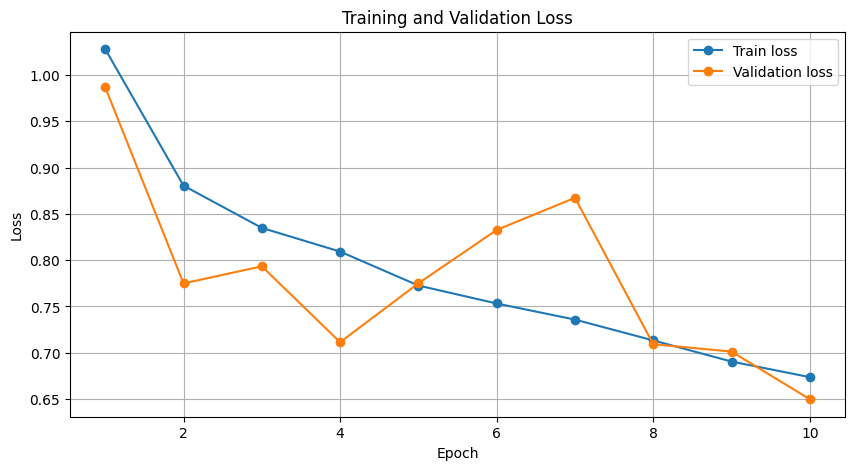

In [ ]:
plt.figure(figsize=(10, 5))

plt.plot(
    history_df["epoch"],
    history_df["train_loss"],
    marker="o",
    label="Train loss",
)

plt.plot(
    history_df["epoch"],
    history_df["validation_loss"],
    marker="o",
    label="Validation loss",
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

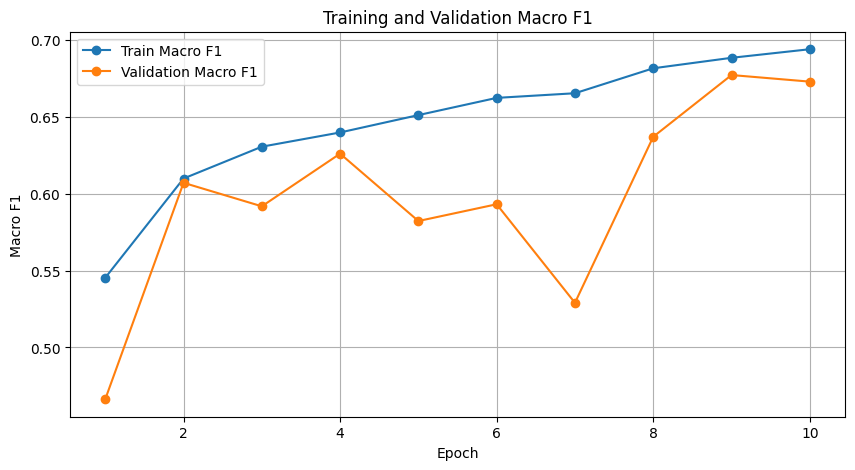

In [ ]:
plt.figure(figsize=(10, 5))

plt.plot(
    history_df["epoch"],
    history_df["train_macro_f1"],
    marker="o",
    label="Train Macro F1",
)

plt.plot(
    history_df["epoch"],
    history_df["validation_macro_f1"],
    marker="o",
    label="Validation Macro F1",
)

plt.xlabel("Epoch")
plt.ylabel("Macro F1")
plt.title("Training and Validation Macro F1")
plt.legend()
plt.grid(True)
plt.show()

# 25단계: 최고 성능 모델 불러오기

In [ ]:
checkpoint = torch.load(
    best_model_path,
    map_location=DEVICE,
)

model.load_state_dict(
    checkpoint["model_state_dict"]
)

print(
    "저장 Epoch:",
    checkpoint["epoch"],
)

print(
    "Validation Macro F1:",
    checkpoint["validation_macro_f1"],
)

저장 Epoch: 9
Validation Macro F1: 0.6771758154927859


# 26단계: Test 데이터 평가

In [ ]:
(
    test_metrics,
    test_labels,
    test_predictions,
) = evaluate_model(
    model=model,
    data_loader=test_loader,
    criterion=criterion,
    device=DEVICE,
)

print("=" * 80)
print("Test 평가 결과")
print("=" * 80)

for metric_name, metric_value in test_metrics.items():
    print(
        f"{metric_name:>12}: "
        f"{metric_value:.4f}"
    )

Test 평가 결과
        loss: 0.6613
    accuracy: 0.7484
    macro_f1: 0.6904
 weighted_f1: 0.7636
       kappa: 0.6613


# 27단계: 클래스별 성능 확인

In [ ]:
report = classification_report(
    test_labels,
    test_predictions,
    labels=[0, 1, 2, 3, 4],
    target_names=CLASS_NAMES,
    digits=4,
    zero_division=0,
    output_dict=True,
)

report_df = pd.DataFrame(
    report
).transpose()

display(report_df)

,precision,recall,f1-score,support
W,0.933491,0.886568,0.909425,9768.000000
N1,0.340098,0.551802,0.420825,3523.000000
N2,0.866660,0.717759,0.785212,11600.000000
N3,0.535035,0.789911,0.637958,1566.000000
REM,0.741255,0.660952,0.698804,4200.000000
accuracy,0.748377,0.748377,0.748377,0.748377
macro avg,0.683308,0.721398,0.690445,30657.000000
weighted avg,0.793323,0.748377,0.763555,30657.000000


In [ ]:
report_df.to_csv(
    OUTPUT_PATH / "cnn_test_classification_report.csv",
    encoding="utf-8-sig",
)

test_metric_df = pd.DataFrame(
    [test_metrics]
)

test_metric_df.to_csv(
    OUTPUT_PATH / "cnn_test_metrics.csv",
    index=False,
    encoding="utf-8-sig",
)

# 28단계: 혼동행렬

In [ ]:
confusion = confusion_matrix(
    test_labels,
    test_predictions,
    labels=[0, 1, 2, 3, 4],
)

confusion_df = pd.DataFrame(
    confusion,
    index=CLASS_NAMES,
    columns=CLASS_NAMES,
)

display(confusion_df)

,W,N1,N2,N3,REM
W,8660,1011,16,9,72
N1,344,1944,688,82,465
N2,60,1811,8326,978,425
N3,1,18,303,1237,7
REM,212,932,274,6,2776


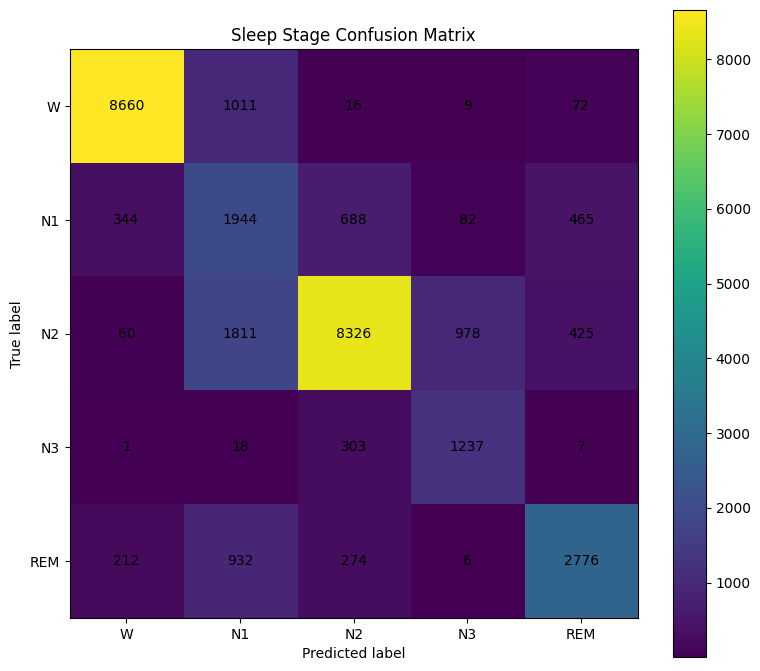

In [ ]:
plt.figure(figsize=(8, 7))

plt.imshow(
    confusion,
    interpolation="nearest",
)

plt.title("Sleep Stage Confusion Matrix")
plt.xlabel("Predicted label")
plt.ylabel("True label")

plt.xticks(
    np.arange(len(CLASS_NAMES)),
    CLASS_NAMES,
)

plt.yticks(
    np.arange(len(CLASS_NAMES)),
    CLASS_NAMES,
)

for row_index in range(confusion.shape[0]):
    for column_index in range(confusion.shape[1]):
        plt.text(
            column_index,
            row_index,
            confusion[row_index, column_index],
            horizontalalignment="center",
            verticalalignment="center",
        )

plt.colorbar()
plt.tight_layout()
plt.show()

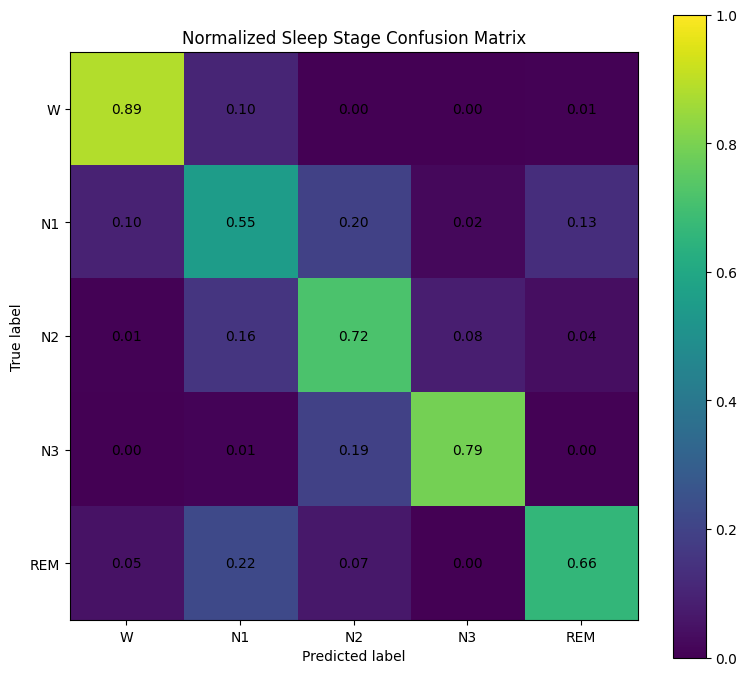

In [ ]:
normalized_confusion = (
    confusion
    / confusion.sum(
        axis=1,
        keepdims=True,
    )
)

normalized_confusion = np.nan_to_num(
    normalized_confusion
)

plt.figure(figsize=(8, 7))

plt.imshow(
    normalized_confusion,
    interpolation="nearest",
    vmin=0,
    vmax=1,
)

plt.title("Normalized Sleep Stage Confusion Matrix")
plt.xlabel("Predicted label")
plt.ylabel("True label")

plt.xticks(
    np.arange(len(CLASS_NAMES)),
    CLASS_NAMES,
)

plt.yticks(
    np.arange(len(CLASS_NAMES)),
    CLASS_NAMES,
)

for row_index in range(
    normalized_confusion.shape[0]
):
    for column_index in range(
        normalized_confusion.shape[1]
    ):
        plt.text(
            column_index,
            row_index,
            f"{normalized_confusion[row_index, column_index]:.2f}",
            horizontalalignment="center",
            verticalalignment="center",
        )

plt.colorbar()
plt.tight_layout()
plt.show()

# 1. CNN + BiLSTM 설정

In [ ]:
# ============================================================
# CNN + BiLSTM 설정
# ============================================================

SEQUENCE_LENGTH = 5

# 가운데 Epoch 위치
CENTER_INDEX = SEQUENCE_LENGTH // 2

BATCH_SIZE = 64

NUMBER_OF_EPOCHS = 15

LEARNING_RATE = 5e-4

WEIGHT_DECAY = 1e-4

EARLY_STOPPING_PATIENCE = 4

if SEQUENCE_LENGTH % 2 == 0:
    raise ValueError(
        "SEQUENCE_LENGTH는 가운데 Epoch를 정하기 위해 "
        "홀수여야 합니다."
    )

print("시퀀스 길이:", SEQUENCE_LENGTH)
print("가운데 Epoch 인덱스:", CENTER_INDEX)

시퀀스 길이: 5
가운데 Epoch 인덱스: 2


# 2. CNN + BiLSTM용 시퀀스 Dataset

In [ ]:
import gc
from pathlib import Path

import numpy as np
import torch
from torch.utils.data import IterableDataset, DataLoader


class SleepEDFSequenceDataset(IterableDataset):
    """
    기록별 NPZ 파일에서 연속된 Epoch 시퀀스를 생성한다.

    입력:
        X_sequence.shape
        = (sequence_length, 1, 3000)

    정답:
        시퀀스 가운데 Epoch의 수면 단계

    중요한 점:
        서로 다른 PSG 기록의 Epoch를 하나의 시퀀스로 연결하지 않는다.
    """

    def __init__(
        self,
        records_df,
        sequence_length: int = 5,
        shuffle: bool = False,
        seed: int = 42,
    ) -> None:
        super().__init__()

        if sequence_length <= 0:
            raise ValueError(
                "sequence_length는 1보다 커야 합니다."
            )

        if sequence_length % 2 == 0:
            raise ValueError(
                "sequence_length는 홀수여야 합니다."
            )

        required_columns = {
            "record_id",
            "subject_id",
            "npz_path",
        }

        missing_columns = (
            required_columns
            - set(records_df.columns)
        )

        if missing_columns:
            raise ValueError(
                "records_df에 필요한 컬럼이 없습니다: "
                f"{sorted(missing_columns)}"
            )

        self.records = records_df[
            [
                "record_id",
                "subject_id",
                "npz_path",
            ]
        ].to_dict("records")

        self.sequence_length = sequence_length
        self.half_window = sequence_length // 2
        self.shuffle = shuffle
        self.seed = seed
        self.epoch = 0

    def set_epoch(
        self,
        epoch: int,
    ) -> None:
        """
        학습 Epoch마다 셔플 순서를 변경하기 위해 사용한다.
        """
        self.epoch = epoch

    def __iter__(self):
        random_generator = np.random.default_rng(
            self.seed + self.epoch
        )

        record_indices = np.arange(
            len(self.records)
        )

        if self.shuffle:
            random_generator.shuffle(
                record_indices
            )

        for record_index in record_indices:
            record = self.records[
                int(record_index)
            ]

            npz_path = Path(
                record["npz_path"]
            )

            if not npz_path.exists():
                raise FileNotFoundError(
                    f"NPZ 파일이 없습니다: {npz_path}"
                )

            with np.load(
                npz_path,
                allow_pickle=False,
            ) as data:
                X = data["X"].astype(
                    np.float32,
                    copy=False,
                )

                y = data["y"].astype(
                    np.int64,
                    copy=False,
                )

            if X.ndim != 3:
                raise RuntimeError(
                    f"X가 3차원이 아닙니다: "
                    f"{npz_path.name}, shape={X.shape}"
                )

            if len(X) != len(y):
                raise RuntimeError(
                    f"X와 y 길이가 다릅니다: "
                    f"{npz_path.name}"
                )

            if len(X) < self.sequence_length:
                print(
                    "[건너뜀] 시퀀스보다 짧은 기록:",
                    npz_path.name,
                )

                del X
                del y
                gc.collect()

                continue

            # 가운데 Epoch가 존재할 수 있는 인덱스
            center_indices = np.arange(
                self.half_window,
                len(y) - self.half_window,
            )

            if self.shuffle:
                random_generator.shuffle(
                    center_indices
                )

            for center_index in center_indices:
                center_index = int(center_index)

                start_index = (
                    center_index
                    - self.half_window
                )

                end_index = (
                    center_index
                    + self.half_window
                    + 1
                )

                X_sequence = X[
                    start_index:end_index
                ]

                y_target = y[
                    center_index
                ]

                if (
                    X_sequence.shape[0]
                    != self.sequence_length
                ):
                    continue

                X_tensor = torch.from_numpy(
                    X_sequence.copy()
                )

                y_tensor = torch.tensor(
                    int(y_target),
                    dtype=torch.long,
                )

                yield X_tensor, y_tensor

            del X
            del y

            gc.collect()

# 3. 시퀀스 수 계산 함수

In [ ]:
def count_sequence_samples(
    records_df,
    sequence_length: int,
) -> int:
    """
    기록별 Epoch 수를 이용해 생성 가능한
    전체 시퀀스 개수를 계산한다.
    """

    total_sequences = 0

    for epoch_count in records_df["epoch_count"]:
        epoch_count = int(epoch_count)

        available_sequences = (
            epoch_count
            - sequence_length
            + 1
        )

        if available_sequences > 0:
            total_sequences += (
                available_sequences
            )

    return total_sequences


train_sequence_count = count_sequence_samples(
    train_df,
    SEQUENCE_LENGTH,
)

validation_sequence_count = count_sequence_samples(
    validation_df,
    SEQUENCE_LENGTH,
)

test_sequence_count = count_sequence_samples(
    test_df,
    SEQUENCE_LENGTH,
)

print(
    "Train 시퀀스 수:",
    f"{train_sequence_count:,}",
)

print(
    "Validation 시퀀스 수:",
    f"{validation_sequence_count:,}",
)

print(
    "Test 시퀀스 수:",
    f"{test_sequence_count:,}",
)

Train 시퀀스 수: 133,146
Validation 시퀀스 수: 31,160
Test 시퀀스 수: 30,561


# 4. Dataset과 DataLoader 생성

In [ ]:
train_sequence_dataset = (
    SleepEDFSequenceDataset(
        records_df=train_df,
        sequence_length=SEQUENCE_LENGTH,
        shuffle=True,
        seed=RANDOM_SEED,
    )
)

validation_sequence_dataset = (
    SleepEDFSequenceDataset(
        records_df=validation_df,
        sequence_length=SEQUENCE_LENGTH,
        shuffle=False,
        seed=RANDOM_SEED,
    )
)

test_sequence_dataset = (
    SleepEDFSequenceDataset(
        records_df=test_df,
        sequence_length=SEQUENCE_LENGTH,
        shuffle=False,
        seed=RANDOM_SEED,
    )
)


train_sequence_loader = DataLoader(
    train_sequence_dataset,
    batch_size=BATCH_SIZE,
    num_workers=0,
    pin_memory=torch.cuda.is_available(),
    drop_last=True,
)

validation_sequence_loader = DataLoader(
    validation_sequence_dataset,
    batch_size=BATCH_SIZE,
    num_workers=0,
    pin_memory=torch.cuda.is_available(),
    drop_last=False,
)

test_sequence_loader = DataLoader(
    test_sequence_dataset,
    batch_size=BATCH_SIZE,
    num_workers=0,
    pin_memory=torch.cuda.is_available(),
    drop_last=False,
)

print("CNN + BiLSTM DataLoader 생성 완료")

CNN + BiLSTM DataLoader 생성 완료


# 5. DataLoader 출력 검증

In [ ]:
X_sequence_batch, y_sequence_batch = next(
    iter(train_sequence_loader)
)

print(
    "X sequence batch shape:",
    X_sequence_batch.shape,
)

print(
    "y sequence batch shape:",
    y_sequence_batch.shape,
)

print(
    "X dtype:",
    X_sequence_batch.dtype,
)

print(
    "y dtype:",
    y_sequence_batch.dtype,
)

print(
    "배치 내 고유 라벨:",
    torch.unique(y_sequence_batch),
)

X sequence batch shape: torch.Size([64, 5, 1, 3000])
y sequence batch shape: torch.Size([64])
X dtype: torch.float32
y dtype: torch.int64
배치 내 고유 라벨: tensor([0, 1, 2, 3, 4])


# 6. CNN Epoch Encoder

In [ ]:
import torch.nn as nn


class CNNEpochEncoder(nn.Module):
    """
    30초 EEG Epoch 하나를 특징 벡터로 변환한다.

    입력:
        (batch, 1, 3000)

    출력:
        (batch, feature_dim)
    """

    def __init__(
        self,
        feature_dim: int = 128,
    ) -> None:
        super().__init__()

        self.feature_extractor = nn.Sequential(
            nn.Conv1d(
                in_channels=1,
                out_channels=32,
                kernel_size=25,
                stride=2,
                padding=12,
                bias=False,
            ),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.MaxPool1d(
                kernel_size=4,
                stride=4,
            ),
            nn.Dropout(0.1),

            nn.Conv1d(
                in_channels=32,
                out_channels=64,
                kernel_size=15,
                stride=1,
                padding=7,
                bias=False,
            ),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.MaxPool1d(
                kernel_size=4,
                stride=4,
            ),
            nn.Dropout(0.2),

            nn.Conv1d(
                in_channels=64,
                out_channels=128,
                kernel_size=9,
                stride=1,
                padding=4,
                bias=False,
            ),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.MaxPool1d(
                kernel_size=4,
                stride=4,
            ),
            nn.Dropout(0.3),

            nn.Conv1d(
                in_channels=128,
                out_channels=256,
                kernel_size=5,
                stride=1,
                padding=2,
                bias=False,
            ),
            nn.BatchNorm1d(256),
            nn.ReLU(),

            nn.AdaptiveAvgPool1d(1),
        )

        self.projection = nn.Sequential(
            nn.Flatten(),
            nn.Linear(
                256,
                feature_dim,
            ),
            nn.ReLU(),
            nn.Dropout(0.3),
        )

    def forward(
        self,
        x: torch.Tensor,
    ) -> torch.Tensor:
        x = self.feature_extractor(x)
        x = self.projection(x)

        return x

# 7. CNN + BiLSTM 모델

In [ ]:
class SleepStageCNNBiLSTM(nn.Module):
    """
    CNN + BiLSTM 기반 수면 단계 분류 모델.

    처리 과정
    ---------
    1. 연속된 각 Epoch를 CNN에 독립적으로 입력
    2. 각 Epoch를 특징 벡터로 변환
    3. 특징 벡터의 시간 순서를 BiLSTM으로 처리
    4. 가운데 Epoch 위치의 BiLSTM 출력을 분류

    입력:
        (batch, sequence_length, 1, 3000)

    출력:
        (batch, 5)
    """

    def __init__(
        self,
        number_of_classes: int = 5,
        cnn_feature_dim: int = 128,
        lstm_hidden_size: int = 128,
        lstm_layers: int = 1,
        dropout: float = 0.4,
    ) -> None:
        super().__init__()

        self.cnn_feature_dim = cnn_feature_dim
        self.lstm_hidden_size = lstm_hidden_size
        self.lstm_layers = lstm_layers

        self.epoch_encoder = CNNEpochEncoder(
            feature_dim=cnn_feature_dim
        )

        self.bilstm = nn.LSTM(
            input_size=cnn_feature_dim,
            hidden_size=lstm_hidden_size,
            num_layers=lstm_layers,
            batch_first=True,
            bidirectional=True,

            # PyTorch LSTM 내부 dropout은
            # layer가 2개 이상일 때만 적용된다.
            dropout=(
                dropout
                if lstm_layers > 1
                else 0.0
            ),
        )

        self.classifier = nn.Sequential(
            nn.LayerNorm(
                lstm_hidden_size * 2
            ),
            nn.Linear(
                lstm_hidden_size * 2,
                128,
            ),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(
                128,
                number_of_classes,
            ),
        )

    def forward(
        self,
        x: torch.Tensor,
    ) -> torch.Tensor:
        """
        x shape:
            (batch, sequence, channel, samples)
        """

        if x.ndim != 4:
            raise ValueError(
                "입력은 4차원이어야 합니다. "
                f"현재 shape: {x.shape}"
            )

        batch_size = x.size(0)
        sequence_length = x.size(1)

        # 각 Epoch를 CNN에 넣기 위해
        # batch와 sequence 차원을 합친다.
        x = x.reshape(
            batch_size * sequence_length,
            x.size(2),
            x.size(3),
        )

        epoch_features = self.epoch_encoder(x)

        # 다시 시퀀스 형태로 복원
        epoch_features = epoch_features.reshape(
            batch_size,
            sequence_length,
            self.cnn_feature_dim,
        )

        # BiLSTM 출력:
        # (batch, sequence, hidden_size * 2)
        sequence_output, _ = self.bilstm(
            epoch_features
        )

        center_index = sequence_length // 2

        # 예측 대상인 가운데 Epoch의 출력만 선택
        center_output = sequence_output[
            :,
            center_index,
            :,
        ]

        logits = self.classifier(
            center_output
        )

        return logits

# 8. 모델 생성 및 출력 검증

In [ ]:
DEVICE = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

cnn_bilstm_model = SleepStageCNNBiLSTM(
    number_of_classes=5,
    cnn_feature_dim=128,
    lstm_hidden_size=128,
    lstm_layers=1,
    dropout=0.4,
).to(DEVICE)

print("사용 장치:", DEVICE)
print(cnn_bilstm_model)

total_parameters = sum(
    parameter.numel()
    for parameter
    in cnn_bilstm_model.parameters()
)

trainable_parameters = sum(
    parameter.numel()
    for parameter
    in cnn_bilstm_model.parameters()
    if parameter.requires_grad
)

print(
    f"전체 파라미터 수: "
    f"{total_parameters:,}"
)

print(
    f"학습 가능 파라미터 수: "
    f"{trainable_parameters:,}"
)

사용 장치: cuda
SleepStageCNNBiLSTM(
  (epoch_encoder): CNNEpochEncoder(
    (feature_extractor): Sequential(
      (0): Conv1d(1, 32, kernel_size=(25,), stride=(2,), padding=(12,), bias=False)
      (1): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU()
      (3): MaxPool1d(kernel_size=4, stride=4, padding=0, dilation=1, ceil_mode=False)
      (4): Dropout(p=0.1, inplace=False)
      (5): Conv1d(32, 64, kernel_size=(15,), stride=(1,), padding=(7,), bias=False)
      (6): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (7): ReLU()
      (8): MaxPool1d(kernel_size=4, stride=4, padding=0, dilation=1, ceil_mode=False)
      (9): Dropout(p=0.2, inplace=False)
      (10): Conv1d(64, 128, kernel_size=(9,), stride=(1,), padding=(4,), bias=False)
      (11): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (12): ReLU()
      (13): MaxPool1d(kernel_size=4, stride=4, padding=0,

In [ ]:
with torch.no_grad():
    sample_logits = cnn_bilstm_model(
        X_sequence_batch[:4].to(DEVICE)
    )

print(
    "모델 출력 shape:",
    sample_logits.shape,
)

모델 출력 shape: torch.Size([4, 5])


# 9. 손실 함수, Optimizer, Scheduler

In [ ]:
class_weights_tensor = (
    class_weights_tensor.to(DEVICE)
)

cnn_bilstm_criterion = nn.CrossEntropyLoss(
    weight=class_weights_tensor
)

cnn_bilstm_optimizer = torch.optim.AdamW(
    cnn_bilstm_model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
)

cnn_bilstm_scheduler = (
    torch.optim.lr_scheduler.ReduceLROnPlateau(
        cnn_bilstm_optimizer,
        mode="max",
        factor=0.5,
        patience=2,
    )
)

print("CNN + BiLSTM 학습 설정 완료")

CNN + BiLSTM 학습 설정 완료


# 10. 학습 함수

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    cohen_kappa_score,
)


def train_sequence_model_one_epoch(
    model,
    data_loader,
    criterion,
    optimizer,
    device,
):
    model.train()

    total_loss = 0.0
    total_samples = 0

    all_labels = []
    all_predictions = []

    for X_batch, y_batch in data_loader:
        X_batch = X_batch.to(
            device,
            non_blocking=True,
        )

        y_batch = y_batch.to(
            device,
            non_blocking=True,
        )

        optimizer.zero_grad(
            set_to_none=True
        )

        logits = model(X_batch)

        loss = criterion(
            logits,
            y_batch,
        )

        loss.backward()

        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            max_norm=5.0,
        )

        optimizer.step()

        batch_size = y_batch.size(0)

        total_loss += (
            loss.item() * batch_size
        )

        total_samples += batch_size

        predictions = torch.argmax(
            logits,
            dim=1,
        )

        all_labels.extend(
            y_batch.detach().cpu().numpy()
        )

        all_predictions.extend(
            predictions.detach().cpu().numpy()
        )

    if total_samples == 0:
        raise RuntimeError(
            "학습 데이터가 한 개도 생성되지 않았습니다."
        )

    all_labels = np.asarray(
        all_labels,
        dtype=np.int64,
    )

    all_predictions = np.asarray(
        all_predictions,
        dtype=np.int64,
    )

    return {
        "loss": total_loss / total_samples,

        "accuracy": accuracy_score(
            all_labels,
            all_predictions,
        ),

        "macro_f1": f1_score(
            all_labels,
            all_predictions,
            average="macro",
            zero_division=0,
        ),

        "weighted_f1": f1_score(
            all_labels,
            all_predictions,
            average="weighted",
            zero_division=0,
        ),

        "kappa": cohen_kappa_score(
            all_labels,
            all_predictions,
        ),
    }

# 11. 평가 함수

In [ ]:
@torch.no_grad()
def evaluate_sequence_model(
    model,
    data_loader,
    criterion,
    device,
):
    model.eval()

    total_loss = 0.0
    total_samples = 0

    all_labels = []
    all_predictions = []

    for X_batch, y_batch in data_loader:
        X_batch = X_batch.to(
            device,
            non_blocking=True,
        )

        y_batch = y_batch.to(
            device,
            non_blocking=True,
        )

        logits = model(X_batch)

        loss = criterion(
            logits,
            y_batch,
        )

        batch_size = y_batch.size(0)

        total_loss += (
            loss.item() * batch_size
        )

        total_samples += batch_size

        predictions = torch.argmax(
            logits,
            dim=1,
        )

        all_labels.extend(
            y_batch.cpu().numpy()
        )

        all_predictions.extend(
            predictions.cpu().numpy()
        )

    if total_samples == 0:
        raise RuntimeError(
            "평가 데이터가 한 개도 생성되지 않았습니다."
        )

    all_labels = np.asarray(
        all_labels,
        dtype=np.int64,
    )

    all_predictions = np.asarray(
        all_predictions,
        dtype=np.int64,
    )

    metrics = {
        "loss": total_loss / total_samples,

        "accuracy": accuracy_score(
            all_labels,
            all_predictions,
        ),

        "macro_f1": f1_score(
            all_labels,
            all_predictions,
            average="macro",
            zero_division=0,
        ),

        "weighted_f1": f1_score(
            all_labels,
            all_predictions,
            average="weighted",
            zero_division=0,
        ),

        "kappa": cohen_kappa_score(
            all_labels,
            all_predictions,
        ),
    }

    return (
        metrics,
        all_labels,
        all_predictions,
    )

# 12. CNN + BiLSTM 학습

In [ ]:
import time
import pandas as pd


best_validation_macro_f1 = -np.inf

best_epoch = 0

epochs_without_improvement = 0

cnn_bilstm_history = []

cnn_bilstm_model_path = (
    MODEL_PATH
    / "best_sleep_stage_cnn_bilstm.pt"
)

training_start_time = time.perf_counter()


for epoch in range(
    1,
    NUMBER_OF_EPOCHS + 1,
):
    epoch_start_time = time.perf_counter()

    train_sequence_dataset.set_epoch(
        epoch
    )

    train_metrics = (
        train_sequence_model_one_epoch(
            model=cnn_bilstm_model,
            data_loader=train_sequence_loader,
            criterion=cnn_bilstm_criterion,
            optimizer=cnn_bilstm_optimizer,
            device=DEVICE,
        )
    )

    (
        validation_metrics,
        _,
        _,
    ) = evaluate_sequence_model(
        model=cnn_bilstm_model,
        data_loader=validation_sequence_loader,
        criterion=cnn_bilstm_criterion,
        device=DEVICE,
    )

    cnn_bilstm_scheduler.step(
        validation_metrics["macro_f1"]
    )

    current_learning_rate = (
        cnn_bilstm_optimizer
        .param_groups[0]["lr"]
    )

    epoch_seconds = (
        time.perf_counter()
        - epoch_start_time
    )

    epoch_result = {
        "epoch": epoch,
        "learning_rate": current_learning_rate,

        "train_loss": (
            train_metrics["loss"]
        ),
        "train_accuracy": (
            train_metrics["accuracy"]
        ),
        "train_macro_f1": (
            train_metrics["macro_f1"]
        ),
        "train_weighted_f1": (
            train_metrics["weighted_f1"]
        ),
        "train_kappa": (
            train_metrics["kappa"]
        ),

        "validation_loss": (
            validation_metrics["loss"]
        ),
        "validation_accuracy": (
            validation_metrics["accuracy"]
        ),
        "validation_macro_f1": (
            validation_metrics["macro_f1"]
        ),
        "validation_weighted_f1": (
            validation_metrics["weighted_f1"]
        ),
        "validation_kappa": (
            validation_metrics["kappa"]
        ),

        "epoch_seconds": epoch_seconds,
    }

    cnn_bilstm_history.append(
        epoch_result
    )

    print("=" * 80)
    print(
        f"Epoch "
        f"{epoch:02d}/"
        f"{NUMBER_OF_EPOCHS:02d}"
    )
    print("-" * 80)

    print(
        "Train      | "
        f"Loss: {train_metrics['loss']:.4f} | "
        f"Acc: {train_metrics['accuracy']:.4f} | "
        f"Macro F1: {train_metrics['macro_f1']:.4f} | "
        f"Kappa: {train_metrics['kappa']:.4f}"
    )

    print(
        "Validation | "
        f"Loss: {validation_metrics['loss']:.4f} | "
        f"Acc: {validation_metrics['accuracy']:.4f} | "
        f"Macro F1: {validation_metrics['macro_f1']:.4f} | "
        f"Kappa: {validation_metrics['kappa']:.4f}"
    )

    print(
        "Learning rate:",
        f"{current_learning_rate:.6f}",
    )

    print(
        "Epoch 시간:",
        f"{epoch_seconds / 60:.2f}분",
    )

    if (
        validation_metrics["macro_f1"]
        > best_validation_macro_f1
    ):
        best_validation_macro_f1 = (
            validation_metrics["macro_f1"]
        )

        best_epoch = epoch

        epochs_without_improvement = 0

        torch.save(
            {
                "epoch": epoch,

                "model_state_dict": (
                    cnn_bilstm_model.state_dict()
                ),

                "optimizer_state_dict": (
                    cnn_bilstm_optimizer.state_dict()
                ),

                "validation_metrics": (
                    validation_metrics
                ),

                "sequence_length": (
                    SEQUENCE_LENGTH
                ),

                "cnn_feature_dim": 128,

                "lstm_hidden_size": 128,

                "lstm_layers": 1,

                "class_names": CLASS_NAMES,

                "class_weights": (
                    class_weights_tensor
                    .detach()
                    .cpu()
                    .numpy()
                    .tolist()
                ),

                "random_seed": RANDOM_SEED,
            },
            cnn_bilstm_model_path,
        )

        print(
            "최고 모델 저장:",
            cnn_bilstm_model_path,
        )

    else:
        epochs_without_improvement += 1

        print(
            "Validation Macro F1 미개선:",
            f"{epochs_without_improvement}/"
            f"{EARLY_STOPPING_PATIENCE}",
        )

    if (
        epochs_without_improvement
        >= EARLY_STOPPING_PATIENCE
    ):
        print("=" * 80)
        print(
            "Early stopping 실행"
        )
        print(
            "최고 Epoch:",
            best_epoch,
        )
        print(
            "최고 Validation Macro F1:",
            f"{best_validation_macro_f1:.4f}",
        )

        break


total_training_seconds = (
    time.perf_counter()
    - training_start_time
)

print("=" * 80)
print("CNN + BiLSTM 학습 완료")
print("=" * 80)
print(
    "최고 Epoch:",
    best_epoch,
)
print(
    "최고 Validation Macro F1:",
    f"{best_validation_macro_f1:.4f}",
)
print(
    "전체 학습 시간:",
    f"{total_training_seconds / 60:.2f}분",
)

Epoch 01/15
--------------------------------------------------------------------------------
Train      | Loss: 0.7485 | Acc: 0.7117 | Macro F1: 0.6685 | Kappa: 0.6216
Validation | Loss: 0.8902 | Acc: 0.6485 | Macro F1: 0.6112 | Kappa: 0.5422
Learning rate: 0.000500
Epoch 시간: 2.27분
최고 모델 저장: /content/drive/MyDrive/SleepEDF/models/best_sleep_stage_cnn_bilstm.pt
Epoch 02/15
--------------------------------------------------------------------------------
Train      | Loss: 0.6732 | Acc: 0.7383 | Macro F1: 0.7003 | Kappa: 0.6558
Validation | Loss: 0.9518 | Acc: 0.5103 | Macro F1: 0.5324 | Kappa: 0.4040
Learning rate: 0.000500
Epoch 시간: 2.28분
Validation Macro F1 미개선: 1/4
Epoch 03/15
--------------------------------------------------------------------------------
Train      | Loss: 0.6151 | Acc: 0.7562 | Macro F1: 0.7209 | Kappa: 0.6790
Validation | Loss: 0.7277 | Acc: 0.7483 | Macro F1: 0.6607 | Kappa: 0.6528
Learning rate: 0.000500
Epoch 시간: 2.27분
최고 모델 저장: /content/drive/MyDrive/SleepEDF/

# 13. 학습 기록 저장

In [ ]:
cnn_bilstm_history_df = pd.DataFrame(
    cnn_bilstm_history
)

cnn_bilstm_history_path = (
    OUTPUT_PATH
    / "cnn_bilstm_training_history.csv"
)

cnn_bilstm_history_df.to_csv(
    cnn_bilstm_history_path,
    index=False,
    encoding="utf-8-sig",
)

display(cnn_bilstm_history_df)

print(
    "학습 기록 저장:",
    cnn_bilstm_history_path,
)

,epoch,learning_rate,train_loss,train_accuracy,train_macro_f1,train_weighted_f1,train_kappa,validation_loss,validation_accuracy,validation_macro_f1,validation_weighted_f1,validation_kappa,epoch_seconds
0,1,0.00050,0.748458,0.711704,0.668456,0.724837,0.621640,0.890189,0.648492,0.611177,0.685050,0.542207,136.021766
1,2,0.00050,0.673167,0.738266,0.700257,0.751203,0.655846,0.951841,0.510302,0.532366,0.563411,0.404000,136.927284
2,3,0.00050,0.615085,0.756175,0.720865,0.768505,0.679005,0.727694,0.748299,0.660747,0.755285,0.652770,136.342004
3,4,0.00050,0.597339,0.760975,0.725232,0.772551,0.685225,0.632034,0.735879,0.679397,0.761122,0.650228,138.443335
4,5,0.00050,0.585565,0.759127,0.726973,0.772342,0.683839,0.903640,0.598588,0.571140,0.630549,0.494001,137.649336
5,6,0.00050,0.566249,0.769569,0.735992,0.781702,0.696806,0.905339,0.608248,0.604824,0.663249,0.503749,137.313160
6,7,0.00025,0.558051,0.766008,0.735325,0.778867,0.692864,0.922845,0.659756,0.583774,0.664044,0.547817,136.641332
7,8,0.00025,0.551636,0.775428,0.741704,0.786420,0.704203,0.678644,0.707831,0.669614,0.742413,0.618507,135.747753


학습 기록 저장: /content/drive/MyDrive/SleepEDF/outputs/cnn_bilstm_training_history.csv


# 14. 학습 곡선

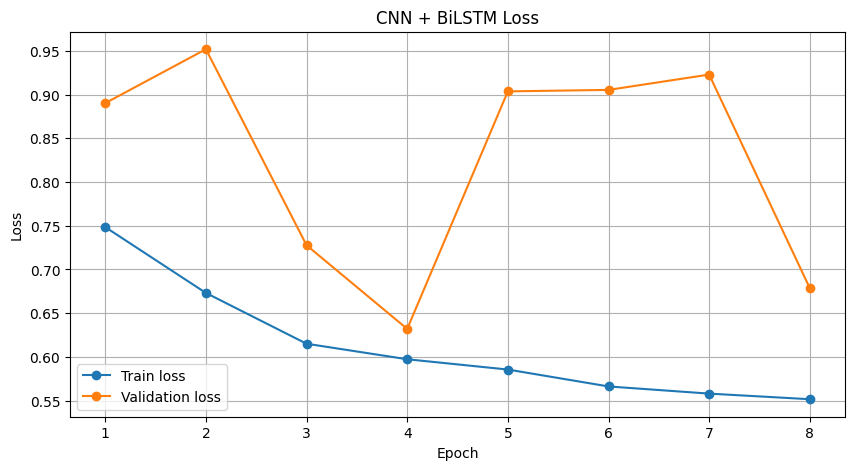

In [ ]:
import matplotlib.pyplot as plt


plt.figure(figsize=(10, 5))

plt.plot(
    cnn_bilstm_history_df["epoch"],
    cnn_bilstm_history_df["train_loss"],
    marker="o",
    label="Train loss",
)

plt.plot(
    cnn_bilstm_history_df["epoch"],
    cnn_bilstm_history_df[
        "validation_loss"
    ],
    marker="o",
    label="Validation loss",
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("CNN + BiLSTM Loss")
plt.legend()
plt.grid(True)
plt.show()

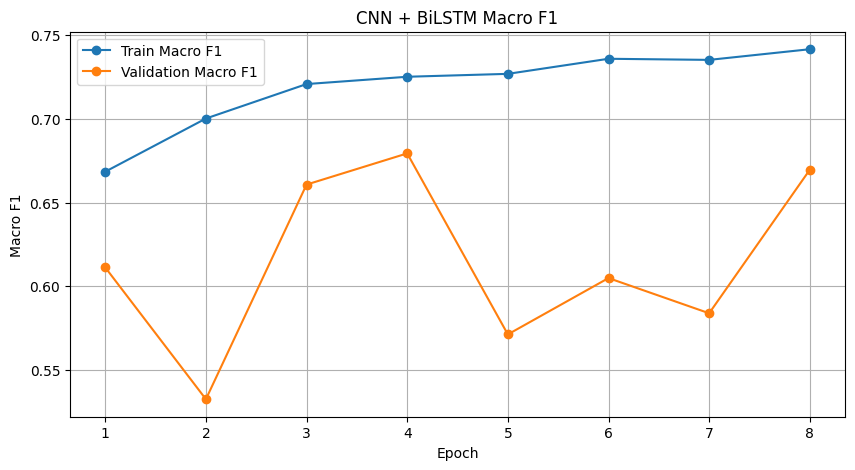

In [ ]:
plt.figure(figsize=(10, 5))

plt.plot(
    cnn_bilstm_history_df["epoch"],
    cnn_bilstm_history_df[
        "train_macro_f1"
    ],
    marker="o",
    label="Train Macro F1",
)

plt.plot(
    cnn_bilstm_history_df["epoch"],
    cnn_bilstm_history_df[
        "validation_macro_f1"
    ],
    marker="o",
    label="Validation Macro F1",
)

plt.xlabel("Epoch")
plt.ylabel("Macro F1")
plt.title("CNN + BiLSTM Macro F1")
plt.legend()
plt.grid(True)
plt.show()

# 15. 최고 모델 불러오기

In [ ]:
checkpoint = torch.load(
    cnn_bilstm_model_path,
    map_location=DEVICE,
    weights_only=False,
)

cnn_bilstm_model.load_state_dict(
    checkpoint["model_state_dict"]
)

print(
    "저장된 최고 Epoch:",
    checkpoint["epoch"],
)

print(
    "저장된 Validation 성능:",
    checkpoint["validation_metrics"],
)

print(
    "시퀀스 길이:",
    checkpoint["sequence_length"],
)

저장된 최고 Epoch: 4
저장된 Validation 성능: {'loss': 0.6320342221284173, 'accuracy': 0.7358793324775353, 'macro_f1': 0.6793972721339803, 'weighted_f1': 0.761122335398942, 'kappa': np.float64(0.6502277070590692)}
시퀀스 길이: 5


# 16. Test 데이터 최종 평가

In [ ]:
(
    cnn_bilstm_test_metrics,
    cnn_bilstm_test_labels,
    cnn_bilstm_test_predictions,
) = evaluate_sequence_model(
    model=cnn_bilstm_model,
    data_loader=test_sequence_loader,
    criterion=cnn_bilstm_criterion,
    device=DEVICE,
)

print("=" * 80)
print("CNN + BiLSTM Test 평가 결과")
print("=" * 80)

for (
    metric_name,
    metric_value,
) in cnn_bilstm_test_metrics.items():
    print(
        f"{metric_name:>12}: "
        f"{metric_value:.4f}"
    )

CNN + BiLSTM Test 평가 결과
        loss: 0.6561
    accuracy: 0.7360
    macro_f1: 0.6876
 weighted_f1: 0.7603
       kappa: 0.6505


# 17. 클래스별 성능 평가

In [ ]:
from sklearn.metrics import (
    classification_report,
)


cnn_bilstm_report = classification_report(
    cnn_bilstm_test_labels,
    cnn_bilstm_test_predictions,
    labels=[0, 1, 2, 3, 4],
    target_names=CLASS_NAMES,
    digits=4,
    zero_division=0,
    output_dict=True,
)

cnn_bilstm_report_df = pd.DataFrame(
    cnn_bilstm_report
).transpose()

display(cnn_bilstm_report_df)

,precision,recall,f1-score,support
W,0.985035,0.775848,0.868016,9672.000000
N1,0.332588,0.633551,0.436193,3523.000000
N2,0.885120,0.715345,0.791228,11600.000000
N3,0.470301,0.738186,0.574553,1566.000000
REM,0.750852,0.786429,0.768229,4200.000000
accuracy,0.736003,0.736003,0.736003,0.736003
macro avg,0.684779,0.729872,0.687644,30561.000000
weighted avg,0.813338,0.736003,0.760339,30561.000000


In [ ]:
cnn_bilstm_report_df.to_csv(
    OUTPUT_PATH
    / "cnn_bilstm_test_classification_report.csv",
    encoding="utf-8-sig",
)

pd.DataFrame(
    [cnn_bilstm_test_metrics]
).to_csv(
    OUTPUT_PATH
    / "cnn_bilstm_test_metrics.csv",
    index=False,
    encoding="utf-8-sig",
)

# 18. 혼동행렬

In [ ]:
from sklearn.metrics import confusion_matrix


cnn_bilstm_confusion = confusion_matrix(
    cnn_bilstm_test_labels,
    cnn_bilstm_test_predictions,
    labels=[0, 1, 2, 3, 4],
)

cnn_bilstm_confusion_df = pd.DataFrame(
    cnn_bilstm_confusion,
    index=CLASS_NAMES,
    columns=CLASS_NAMES,
)

display(cnn_bilstm_confusion_df)

,W,N1,N2,N3,REM
W,7504,1912,26,29,201
N1,99,2232,572,150,470
N2,5,1758,8298,1116,423
N3,0,9,399,1156,2
REM,10,800,80,7,3303


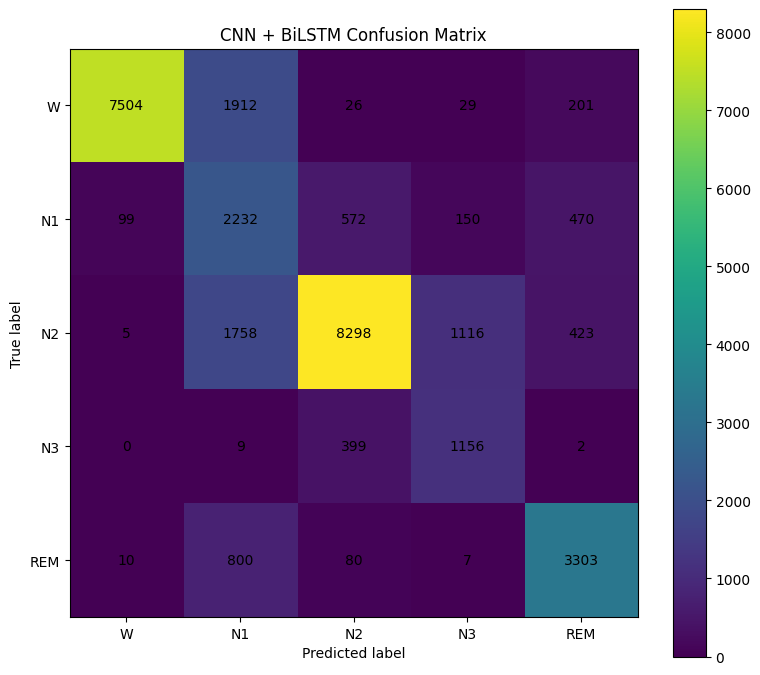

In [ ]:
plt.figure(figsize=(8, 7))

plt.imshow(
    cnn_bilstm_confusion,
    interpolation="nearest",
)

plt.title(
    "CNN + BiLSTM Confusion Matrix"
)

plt.xlabel("Predicted label")
plt.ylabel("True label")

plt.xticks(
    np.arange(len(CLASS_NAMES)),
    CLASS_NAMES,
)

plt.yticks(
    np.arange(len(CLASS_NAMES)),
    CLASS_NAMES,
)

for row_index in range(
    cnn_bilstm_confusion.shape[0]
):
    for column_index in range(
        cnn_bilstm_confusion.shape[1]
    ):
        plt.text(
            column_index,
            row_index,
            cnn_bilstm_confusion[
                row_index,
                column_index,
            ],
            horizontalalignment="center",
            verticalalignment="center",
        )

plt.colorbar()
plt.tight_layout()
plt.show()

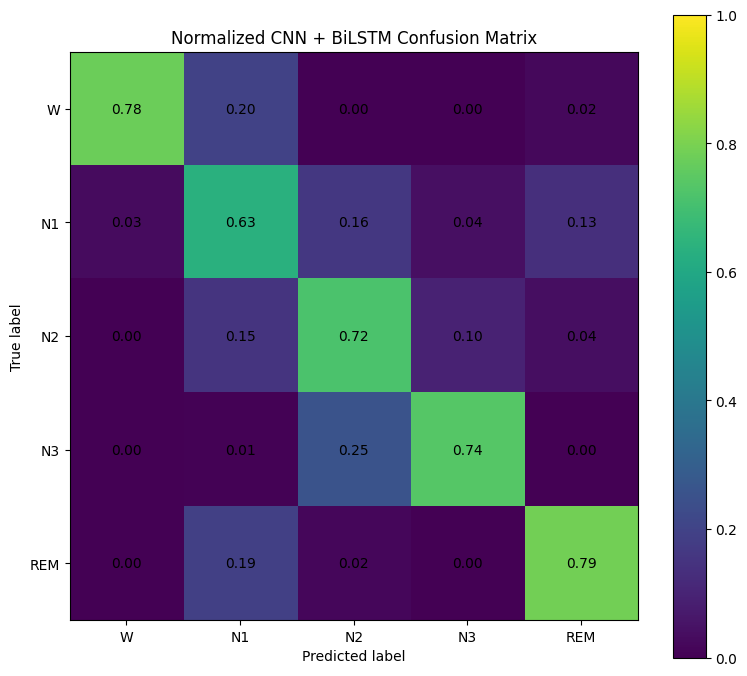

In [ ]:
cnn_bilstm_normalized_confusion = (
    cnn_bilstm_confusion
    / cnn_bilstm_confusion.sum(
        axis=1,
        keepdims=True,
    )
)

cnn_bilstm_normalized_confusion = (
    np.nan_to_num(
        cnn_bilstm_normalized_confusion
    )
)

plt.figure(figsize=(8, 7))

plt.imshow(
    cnn_bilstm_normalized_confusion,
    interpolation="nearest",
    vmin=0,
    vmax=1,
)

plt.title(
    "Normalized CNN + BiLSTM Confusion Matrix"
)

plt.xlabel("Predicted label")
plt.ylabel("True label")

plt.xticks(
    np.arange(len(CLASS_NAMES)),
    CLASS_NAMES,
)

plt.yticks(
    np.arange(len(CLASS_NAMES)),
    CLASS_NAMES,
)

for row_index in range(
    cnn_bilstm_normalized_confusion.shape[0]
):
    for column_index in range(
        cnn_bilstm_normalized_confusion.shape[1]
    ):
        plt.text(
            column_index,
            row_index,
            (
                f"{cnn_bilstm_normalized_confusion[
                    row_index,
                    column_index
                ]:.2f}"
            ),
            horizontalalignment="center",
            verticalalignment="center",
        )

plt.colorbar()
plt.tight_layout()
plt.show()

# 19. 기존 CNN과 CNN + BiLSTM 비교

In [ ]:
cnn_test_metrics = {
    "accuracy": 0.7466,
    "macro_f1": 0.6887,
    "weighted_f1": 0.7631,
    "kappa": 0.6592,
}

model_comparison_df = pd.DataFrame(
    [
        {
            "model": "1D CNN",
            "accuracy": (
                cnn_test_metrics["accuracy"]
            ),
            "macro_f1": (
                cnn_test_metrics["macro_f1"]
            ),
            "weighted_f1": (
                cnn_test_metrics[
                    "weighted_f1"
                ]
            ),
            "kappa": (
                cnn_test_metrics["kappa"]
            ),
        },
        {
            "model": "CNN + BiLSTM",
            "accuracy": (
                cnn_bilstm_test_metrics[
                    "accuracy"
                ]
            ),
            "macro_f1": (
                cnn_bilstm_test_metrics[
                    "macro_f1"
                ]
            ),
            "weighted_f1": (
                cnn_bilstm_test_metrics[
                    "weighted_f1"
                ]
            ),
            "kappa": (
                cnn_bilstm_test_metrics[
                    "kappa"
                ]
            ),
        },
    ]
)

display(model_comparison_df)

,model,accuracy,macro_f1,weighted_f1,kappa
0,1D CNN,0.746600,0.688700,0.763100,0.659200
1,CNN + BiLSTM,0.736003,0.687644,0.760339,0.650546


In [ ]:
model_comparison_df.to_csv(
    OUTPUT_PATH
    / "cnn_vs_cnn_bilstm_comparison.csv",
    index=False,
    encoding="utf-8-sig",
)